In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import pickle
import os
import joblib
from utils import ml_pipeline as ml
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from utils import plotting
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.metrics import accuracy_score

2024-09-25 23:48:23.584052: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
with open('./FEATURES/test-features/dfs/liwc22-size100.pkl', 'rb') as f:
    test_size100 = pickle.load(f)
y_test = test_size100['label']

groups = pd.read_csv('mapping.csv')
groups['mapping'] = groups['mapping'].str.replace('adrsdt', '')
groups.rename(columns={'mapping': 'pid'}, inplace=True)

with open('./evaluation-test-UPD/liwc22-size100-probs.pkl', 'rb') as f:
    liwc_proba100 = pickle.load(f)
liwc_proba100 = liwc_proba100['Random Forest']

# Assuming gpt_proba is a list of 10 numpy arrays
flat_list = [item for sublist in liwc_proba100 for item in sublist]
probas = np.concatenate(liwc_proba100)
df_all = pd.DataFrame(probas.round(2), columns=['prob'])
df_all['pid'] = np.tile(test_size100['pid'], 10)
df_all['y_true'] = np.tile(test_size100['label'], 10)

groups = pd.read_csv('mapping.csv')
groups['merge'] = groups['mapping'].str.extract(r'dt(\d+)')
merged_df_all = df_all.merge(groups, left_on='pid', right_on='merge', how='left')
merged_df_all['gender'] = merged_df_all['gender'].map({'female': 'F', 'male': 'M'}).fillna('NA')
s = ['pid', 'mmse', 'prob', 'y_true', 'mmse_split', 'age_split']
merged_df_all = merged_df_all[s]
# we dont know the value of MMSE but know its CN group
merged_df_all.loc[merged_df_all['pid'] == '54', 'mmse_split'] = 'cn'
merged_df_all.loc[merged_df_all['pid'] == '54', 'mmse'] = 28
# y_test
y_test_boots = merged_df_all.y_true
merged_df_all.head()

# merged_df_all[merged_df_all.pid == '54']

,pid,mmse,prob,y_true,mmse_split,age_split
0,58,29.0,0.24,0,cn,70-80
1,64,24.0,0.52,1,ad-mil,60-69
2,70,18.0,0.60,1,ad-mod,50-59
3,71,24.0,0.83,1,ad-mil,70-80
4,65,30.0,0.25,0,cn,50-59


In [182]:
groups

,adressfname,gender,dx,age,mmse,mapping,mmse_split,age_split,merge
0,adrso004,female,Control,74,30.0,adrsdt15,cn,70-80,15
1,adrso006,female,Control,65,28.0,adrsdt40,cn,60-69,40
2,adrso009,female,Control,68,29.0,adrsdt26,cn,60-69,26
3,adrso011,female,Control,71,30.0,adrsdt67,cn,70-80,67
4,adrso013,female,Control,70,29.0,adrsdt58,cn,70-80,58
...,...,...,...,...,...,...,...,...,...
66,adrso303,male,Control,66,29.0,adrsdt55,cn,60-69,55
67,adrso304,male,Control,70,30.0,adrsdt68,cn,70-80,68
68,adrso313,female,Control,63,28.0,adrsdt31,cn,60-69,31
69,adrso314,female,Control,61,29.0,adrsdt5,cn,60-69,5


In [183]:
groups[groups.mmse_split == 'cn']

,adressfname,gender,dx,age,mmse,mapping,mmse_split,age_split,merge
0,adrso004,female,Control,74,30.0,adrsdt15,cn,70-80,15
1,adrso006,female,Control,65,28.0,adrsdt40,cn,60-69,40
2,adrso009,female,Control,68,29.0,adrsdt26,cn,60-69,26
3,adrso011,female,Control,71,30.0,adrsdt67,cn,70-80,67
4,adrso013,female,Control,70,29.0,adrsdt58,cn,70-80,58
5,adrso020,female,Control,61,28.0,adrsdt49,cn,60-69,49
19,adrso099,female,ProbableAD,79,30.0,adrsdt63,cn,70-80,63
29,adrso149,female,Control,67,29.0,adrsdt38,cn,60-69,38
30,adrso150,male,Control,70,29.0,adrsdt30,cn,70-80,30
31,adrso155,female,Control,70,30.0,adrsdt52,cn,70-80,52


In [188]:
groups[groups.dx == 'ProbableAD']

,adressfname,gender,dx,age,mmse,mapping,mmse_split,age_split,merge
6,adrso029,male,ProbableAD,59,8.0,adrsdt46,ad-sev,50-59,46
7,adrso037,male,ProbableAD,77,10.0,adrsdt8,ad-mod,70-80,8
8,adrso038,female,ProbableAD,65,24.0,adrsdt64,ad-mil,60-69,64
9,adrso041,female,ProbableAD,71,5.0,adrsdt29,ad-sev,70-80,29
10,adrso042,male,ProbableAD,69,25.0,adrsdt59,ad-mil,60-69,59
11,adrso044,female,ProbableAD,77,25.0,adrsdt18,ad-mil,70-80,18
12,adrso052,female,ProbableAD,62,12.0,adrsdt44,ad-mod,60-69,44
13,adrso062,female,ProbableAD,69,19.0,adrsdt61,ad-mod,60-69,61
14,adrso064,male,ProbableAD,73,13.0,adrsdt37,ad-mod,70-80,37
15,adrso065,male,ProbableAD,76,25.0,adrsdt32,ad-mil,70-80,32


In [186]:
merged_df_all[merged_df_all.pid == '4']

,pid,mmse,prob,y_true,mmse_split,age_split
51,4,27.0,0.55,1,cn,60-69
122,4,27.0,0.50,1,cn,60-69
193,4,27.0,0.50,1,cn,60-69
264,4,27.0,0.54,1,cn,60-69
335,4,27.0,0.43,1,cn,60-69
406,4,27.0,0.53,1,cn,60-69
477,4,27.0,0.63,1,cn,60-69
548,4,27.0,0.39,1,cn,60-69
619,4,27.0,0.68,1,cn,60-69
690,4,27.0,0.60,1,cn,60-69


In [187]:
merged_df_all[merged_df_all.pid == '63']

,pid,mmse,prob,y_true,mmse_split,age_split
9,63,30.0,0.71,1,cn,70-80
80,63,30.0,0.64,1,cn,70-80
151,63,30.0,0.45,1,cn,70-80
222,63,30.0,0.46,1,cn,70-80
293,63,30.0,0.61,1,cn,70-80
364,63,30.0,0.65,1,cn,70-80
435,63,30.0,0.59,1,cn,70-80
506,63,30.0,0.78,1,cn,70-80
577,63,30.0,0.82,1,cn,70-80
648,63,30.0,0.69,1,cn,70-80


In [184]:
len(groups[groups.mmse_split == 'cn'])

36

In [181]:
merged_df_all

,pid,mmse,prob,y_true,mmse_split,age_split
0,58,29.0,0.24,0,cn,70-80
1,64,24.0,0.52,1,ad-mil,60-69
2,70,18.0,0.60,1,ad-mod,50-59
3,71,24.0,0.83,1,ad-mil,70-80
4,65,30.0,0.25,0,cn,50-59
...,...,...,...,...,...,...
705,68,30.0,0.14,0,cn,70-80
706,69,30.0,0.46,0,cn,50-59
707,55,29.0,0.10,0,cn,60-69
708,41,20.0,0.43,1,ad-mod,50-59


### Confusion matrix

In [165]:
y_pred = (np.array(merged_df_all.prob) > 0.5).astype(int)
len(y_pred)

710

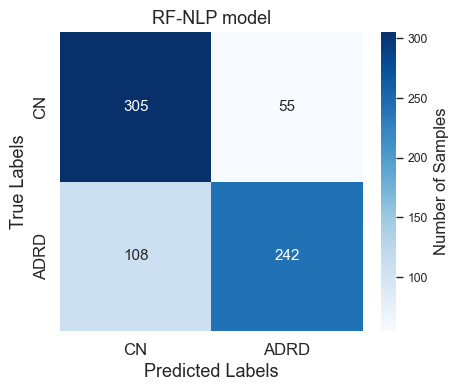

In [166]:
cm = confusion_matrix(y_test_boots, y_pred)
with plotting.paper_theme():
    plt.figure(figsize=(4.7,4))
    ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, xticklabels=['CN', 'ADRD'], 
                yticklabels=['CN', 'ADRD'],
                annot_kws={"size": 11}
                )
    cbar = ax.collections[0].colorbar
    cbar.set_label('Number of Samples', fontsize=12)
    plt.xlabel('Predicted Labels', fontsize=13)
    plt.ylabel('True Labels', fontsize=13)
    plt.title('RF-NLP model', fontsize=13)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    plt.savefig('./[figs]/conf_matrix_nlp.pdf', dpi=600)
    plt.savefig('./[figs]/conf_matrix_nlp.png', dpi=600)
    plt.show()


GPT updated

In [5]:
with open('./FEATURES/test-features/dfs/gpt_new.pkl', 'rb') as f: # new
    df_gpt_test = pickle.load(f)
df_gpt_test['pid'] = df_gpt_test['pid'].str.replace('adrsdt', '')
y_test_gpt = df_gpt_test['label']

groups = pd.read_csv('mapping.csv')
groups['mapping'] = groups['mapping'].str.replace('adrsdt', '')
groups.rename(columns={'mapping': 'pid'}, inplace=True)

with open('./evaluation-test-UPD/gpt_probs.pkl', 'rb') as f:
    gpt_proba = pickle.load(f)
gpt_proba = gpt_proba['Neural Network']

# Assuming gpt_proba is a list of 10 numpy arrays
flat_list = [item for sublist in gpt_proba for item in sublist]
probas = np.concatenate(gpt_proba)
df_all = pd.DataFrame(probas.round(2), columns=['prob'])
df_all['pid'] = np.tile(df_gpt_test['pid'], 10)
df_all['y_true'] = np.tile(df_gpt_test['label'], 10)

groups = pd.read_csv('mapping.csv')
groups['merge'] = groups['mapping'].str.extract(r'dt(\d+)')
merged_df_all = df_all.merge(groups, left_on='pid', right_on='merge', how='left')
merged_df_all['gender'] = merged_df_all['gender'].map({'female': 'F', 'male': 'M'}).fillna('NA')
s = ['pid', 'mmse', 'prob', 'y_true', 'mmse_split']
merged_df_all = merged_df_all[s]
# we dont know the value of MMSE but know its CN group
merged_df_all.loc[merged_df_all['pid'] == '54', 'mmse_split'] = 'cn'
merged_df_all.loc[merged_df_all['pid'] == '54', 'mmse'] = 28
# y_test
y_test_boots = merged_df_all.y_true
merged_df_all.head()

# merged_df_all[merged_df_all.pid == '54']

,pid,mmse,prob,y_true,mmse_split
0,1,19.0,0.97,1,ad-mod
1,10,27.0,0.35,0,cn
2,11,30.0,0.05,0,cn
3,12,30.0,0.00,0,cn
4,13,20.0,0.58,1,ad-mod


In [6]:
y_pred = (np.array(merged_df_all.prob) > 0.5).astype(int)
len(y_pred)

710

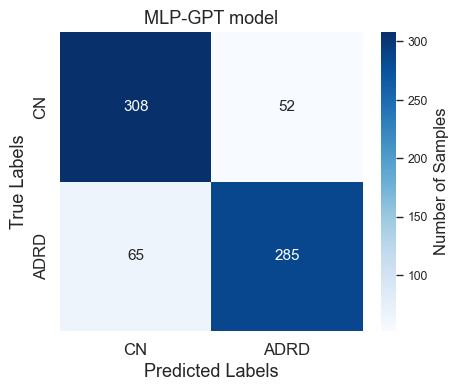

In [7]:
cm = confusion_matrix(y_test_boots, y_pred)

with plotting.paper_theme():
    plt.figure(figsize=(4.7,4))
    ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, xticklabels=['CN', 'ADRD'], 
                yticklabels=['CN', 'ADRD'],
                annot_kws={"size": 11}
                )
    cbar = ax.collections[0].colorbar
    cbar.set_label('Number of Samples', fontsize=12)
    plt.xlabel('Predicted Labels', fontsize=13)
    plt.ylabel('True Labels', fontsize=13)
    plt.title('MLP-GPT model', fontsize=13)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    plt.savefig('./[figs]/conf_matrix_gpt.pdf', dpi=600)
    plt.savefig('./[figs]/conf_matrix_gpt.png', dpi=600)
    plt.show()


### Plot age splits

In [173]:
age_1_idx = merged_df_all[merged_df_all.age_split == '50-59'].index.tolist()
age_2_idx = merged_df_all[merged_df_all.age_split == '60-69'].index.tolist()
age_3_idx = merged_df_all[merged_df_all.age_split == '70-80'].index.tolist()
len(age_1_idx), len(age_2_idx), len(age_3_idx)

age_1_1 = merged_df_all[(merged_df_all.age_split == '50-59') & (merged_df_all.y_true == 1)].shape[0]
age_1_0 = merged_df_all[(merged_df_all.age_split == '50-59') & (merged_df_all.y_true == 0)].shape[0]
age_2_1 = merged_df_all[(merged_df_all.age_split == '60-69') & (merged_df_all.y_true == 1)].shape[0]
age_2_0 = merged_df_all[(merged_df_all.age_split == '60-69') & (merged_df_all.y_true == 0)].shape[0]
age_3_1 = merged_df_all[(merged_df_all.age_split == '70-80') & (merged_df_all.y_true == 1)].shape[0]
age_3_0 = merged_df_all[(merged_df_all.age_split == '70-80') & (merged_df_all.y_true == 0)].shape[0]

round(age_1_0/age_1_1, 1), round(age_2_0/age_2_1, 1), round(age_3_0/age_3_1, 1)

(1.3, 1.2, 0.8)

In [174]:
tp_age_1, tn_age_1, fp_age_1, fn_age_1 = ml.calc_items(0.5, merged_df_all.prob, y_test_boots, age_1_idx)
tp_age_2, tn_age_2, fp_age_2, fn_age_2 = ml.calc_items(0.5, merged_df_all.prob, y_test_boots, age_2_idx)
tp_age_3, tn_age_3, fp_age_3, fn_age_3 = ml.calc_items(0.5, merged_df_all.prob, y_test_boots, age_3_idx)

/var/folders/xx/gc1pd92159b41vdn712h03ym0000gp/T/ipykernel_6748/800248738.py:59: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(['{:.0f}'.format(y*100) for y in ax.get_yticks()], fontsize=10)


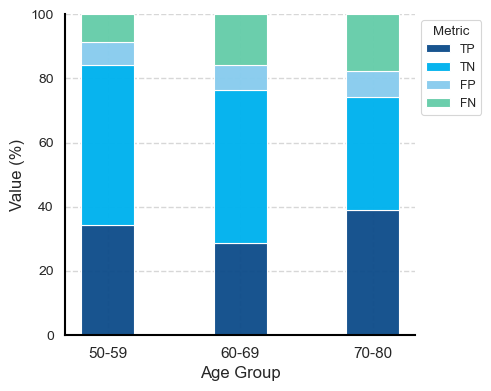

In [176]:
# Calculating the totals for female and male
total_age1 = tp_age_1+ tn_age_1+ fp_age_1+ fn_age_1
total_age2 = tp_age_2+ tn_age_2+ fp_age_2+ fn_age_2
total_age3 = tp_age_3+ tn_age_3+ fp_age_3+ fn_age_3

# Calculating the proportions
props_age1 = [x / total_age1 for x in [tp_age_1, tn_age_1, fp_age_1, fn_age_1]]
props_age2 = [x / total_age2 for x in [tp_age_2, tn_age_2, fp_age_2, fn_age_2]]
props_age3 = [x / total_age3 for x in [tp_age_3, tn_age_3, fp_age_3, fn_age_3]]

categories = ['50-59', '60-69', '70-80']


colors = [
    "#104E8B",
    "#00B2EE",
    "#88CCEE",
    # "lightskyblue",
    # "mediumturquoise",
    "mediumaquamarine",
    # "#48D1CC",
    # "#44AA99",
    # "#117733",  
]  # Colors for TP, TN, FP, FN respectively

colors = [mcolors.to_rgba(c, alpha=0.97) for c in colors]

# Plotting
with plotting.paper_theme():
    fig, ax = plt.subplots(figsize=(5, 4))

    bar_width = 0.4

    bottom = 0
    for i, prop in enumerate(props_age1):
        ax.bar(categories[0], prop, width=bar_width, bottom=bottom, color=colors[i], edgecolor='white')
        bottom += prop


    bottom = 0
    for i, prop in enumerate(props_age2):
        ax.bar(categories[1], prop, width=bar_width, bottom=bottom, color=colors[i], edgecolor='white')
        bottom += prop


    bottom = 0
    for i, prop in enumerate(props_age3):
        ax.bar(categories[2], prop, width=bar_width, bottom=bottom, color=colors[i], edgecolor='white')
        bottom += prop

    ax.set_ylabel('Value (%)', fontsize=12)
    ax.set_xlabel('Age Group', fontsize=12)
    # ax.set_xticklabels(ax.get_xticks(), fontsize=10)
    # ax.set_title('Confusion Matrix Metrics by Age (GPT features)')
    ax.legend(['TP', 'TN', 'FP', 'FN'], title='Metric', bbox_to_anchor=(1, 1))

    # Adjusting the y-axis to show percentages
    ax.set_ylim(0, 1)
    ax.set_yticklabels(['{:.0f}'.format(y*100) for y in ax.get_yticks()], fontsize=10)
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(categories, fontsize=11)
    plt.tight_layout()
    plt.savefig('./[figs]/splits_age.pdf', dpi=600)
    plt.savefig('./[figs]/splits_age.png', dpi=600)
    plt.show()

### Plot MMSE splits

In [142]:
with open('./FEATURES/test-features/dfs/liwc22-size100.pkl', 'rb') as f:
    test_size100 = pickle.load(f)
y_test = test_size100['label']

groups = pd.read_csv('mapping.csv')
groups['mapping'] = groups['mapping'].str.replace('adrsdt', '')
groups.rename(columns={'mapping': 'pid'}, inplace=True)

with open('./evaluation-test-UPD/liwc22-size100-probs.pkl', 'rb') as f:
    liwc_proba100 = pickle.load(f)
liwc_proba100 = liwc_proba100['Random Forest']

df = test_size100.merge(groups, left_on='pid', right_on='pid', how='left')
df['gender'] = df['gender'].map({'female': 'F', 'male': 'M'}).fillna('NA')
liwc_groups = df.copy()

In [143]:
df

,pid,label,data,adressfname,gender,dx,age,mmse,mmse_split,age_split
0,58,0,"[57, 47.02, 94.48, 1.0, 5.65, 8.14, 14.04, 89....",adrso013,F,Control,70,29.0,cn,70-80
1,64,1,"[57, 62.72, 70.59, 14.46, 74.93, 5.7, 15.79, 9...",adrso038,F,ProbableAD,65,24.0,ad-mil,60-69
2,70,1,"[62, 95.94, 97.31, 25.64, 6.37, 4.43, 6.45, 95...",adrso214,M,ProbableAD,56,18.0,ad-mod,50-59
3,71,1,"[156, 1.0, 99.0, 1.31, 49.66, 19.5, 13.46, 97....",adrso083,M,ProbableAD,78,24.0,ad-mil,70-80
4,65,0,"[107, 88.19, 94.26, 10.52, 48.73, 15.29, 12.15...",adrso166,F,Control,58,30.0,cn,50-59
...,...,...,...,...,...,...,...,...,...,...
66,68,0,"[113, 86.9, 79.24, 53.37, 20.23, 12.56, 15.93,...",adrso304,M,Control,70,30.0,cn,70-80
67,69,0,"[111, 99.0, 93.46, 98.8, 32.75, 6.53, 15.32, 8...",adrso288,F,Control,59,30.0,cn,50-59
68,55,0,"[248, 74.04, 86.1, 6.29, 25.43, 9.92, 15.32, 8...",adrso303,M,Control,66,29.0,cn,60-69
69,41,1,"[49, 97.86, 74.89, 66.12, 82.06, 12.25, 14.29,...",adrso132,M,ProbableAD,58,20.0,ad-mod,50-59


In [146]:
liwc_proba100

[array([0.24378571, 0.5242619 , 0.60224603, 0.83431746, 0.24952381,
        0.34054762, 0.5516746 , 0.16938095, 0.54938095, 0.71452381,
        0.43909524, 0.44961111, 0.59985714, 0.19633333, 0.65466667,
        0.83136508, 0.55935714, 0.25355556, 0.24871429, 0.40209524,
        0.17602381, 0.84638095, 0.5132381 , 0.85795238, 0.69538095,
        0.58938095, 0.39034921, 0.68904762, 0.38628571, 0.54380952,
        0.77684921, 0.30096825, 0.61783333, 0.42660317, 0.48219048,
        0.6377619 , 0.30633333, 0.30989683, 0.3994127 , 0.35953968,
        0.53088889, 0.5074127 , 0.33202381, 0.89990476, 0.27163492,
        0.12519048, 0.36547619, 0.393     , 0.52159524, 0.35722222,
        0.70088889, 0.553     , 0.186     , 0.36026984, 0.80166667,
        0.27247619, 0.29590476, 0.829     , 0.44177778, 0.70854762,
        0.45446032, 0.32738095, 0.47414286, 0.40652381, 0.38407937,
        0.11785714, 0.30519048, 0.67712698, 0.1588254 , 0.49387302,
        0.85557143]),
 array([0.39078571, 0.79  

In [150]:
# Assuming gpt_proba is a list of 10 numpy arrays
flat_list = [item for sublist in liwc_proba100 for item in sublist]
probas = np.concatenate(liwc_proba100)
df_all = pd.DataFrame(probas.round(2), columns=['prob'])
df_all['pid'] = np.tile(test_size100['pid'], 10)
df_all['y_true'] = np.tile(test_size100['label'], 10)

groups = pd.read_csv('mapping.csv')
groups['merge'] = groups['mapping'].str.extract(r'dt(\d+)')
merged_df_all = df_all.merge(groups, left_on='pid', right_on='merge', how='left')
merged_df_all['gender'] = merged_df_all['gender'].map({'female': 'F', 'male': 'M'}).fillna('NA')
s = ['pid', 'mmse', 'prob', 'y_true', 'mmse_split']
merged_df_all = merged_df_all[s]
# we dont know the value of MMSE but know its CN group
merged_df_all.loc[merged_df_all['pid'] == '54', 'mmse_split'] = 'cn'
merged_df_all.loc[merged_df_all['pid'] == '54', 'mmse'] = 28
merged_df_all.head()

merged_df_all[merged_df_all.pid == '54']

,pid,mmse,prob,y_true,mmse_split
65,54,28.0,0.12,0,cn
136,54,28.0,0.09,0,cn
207,54,28.0,0.30,0,cn
278,54,28.0,0.16,0,cn
349,54,28.0,0.12,0,cn
420,54,28.0,0.11,0,cn
491,54,28.0,0.04,0,cn
562,54,28.0,0.14,0,cn
633,54,28.0,0.24,0,cn
704,54,28.0,0.13,0,cn


In [151]:
merged_df_all

,pid,mmse,prob,y_true,mmse_split
0,58,29.0,0.24,0,cn
1,64,24.0,0.52,1,ad-mil
2,70,18.0,0.60,1,ad-mod
3,71,24.0,0.83,1,ad-mil
4,65,30.0,0.25,0,cn
...,...,...,...,...,...
705,68,30.0,0.14,0,cn
706,69,30.0,0.46,0,cn
707,55,29.0,0.10,0,cn
708,41,20.0,0.43,1,ad-mod


In [152]:
y_test_boots = merged_df_all.y_true

In [153]:
mmse_1_idx = merged_df_all[merged_df_all.mmse_split == 'cn'].index.tolist()
mmse_2_idx = merged_df_all[merged_df_all.mmse_split == 'ad-mil'].index.tolist()
mmse_3_idx = merged_df_all[merged_df_all.mmse_split == 'ad-mod'].index.tolist()
# mmse_4_idx = df_nlp[df_nlp.mmse_split == 'ad-sev'].index.tolist()
tp_mmse_1, tn_mmse_1, fp_mmse_1, fn_mmse_1 = ml.calc_items(0.5, merged_df_all.prob, y_test_boots, mmse_1_idx)
tp_mmse_2, tn_mmse_2, fp_mmse_2, fn_mmse_2 = ml.calc_items(0.5, merged_df_all.prob, y_test_boots, mmse_2_idx)
tp_mmse_3, tn_mmse_3, fp_mmse_3, fn_mmse_3 = ml.calc_items(0.5, merged_df_all.prob, y_test_boots, mmse_3_idx)
# tp_mmse_4, tn_mmse_4, fp_mmse_4, fn_mmse_4 = calc_items(0.5, df_nlp.probs, y_test_boots_excluded, mmse_4_idx)

acc_mmse_1= (tp_mmse_1+tn_mmse_1)/(tp_mmse_1+ tn_mmse_1+ fp_mmse_1+ fn_mmse_1)
acc_mmse_2= (tp_mmse_2+tn_mmse_2)/(tp_mmse_2+ tn_mmse_2+ fp_mmse_2+ fn_mmse_2)
acc_mmse_3 = (tp_mmse_3+tn_mmse_3)/(tp_mmse_3+ tn_mmse_3+ fp_mmse_3+ fn_mmse_3)
acc_mmse_1.round(3), acc_mmse_2.round(3),acc_mmse_3.round(3)

# Calculating the totals for female and male
total_mmse1 = tp_mmse_1+ tn_mmse_1+ fp_mmse_1+ fn_mmse_1
total_mmse2 = tp_mmse_2+ tn_mmse_2+ fp_mmse_2+ fn_mmse_2
total_mmse3 = tp_mmse_3+ tn_mmse_3+ fp_mmse_3+ fn_mmse_3
# total_mmse4 = tp_mmse_4+ tn_mmse_4+ fp_mmse_4+ fn_mmse_4

# Calculating the proportions
props_mmse1 = [x / total_mmse1 for x in [tp_mmse_1, tn_mmse_1, fp_mmse_1, fn_mmse_1]]
props_mmse2 = [x / total_mmse2 for x in [tp_mmse_2, tn_mmse_2, fp_mmse_2, fn_mmse_2]]
props_mmse3 = [x / total_mmse3 for x in [tp_mmse_3, tn_mmse_3, fp_mmse_3, fn_mmse_3]]
# props_mmse4 = [x / total_mmse4 for x in [tp_mmse_4, tn_mmse_4, fp_mmse_4, fn_mmse_4]]


In [154]:
props_mmse1

[0.03783783783783784,
 0.7972972972972973,
 0.14864864864864866,
 0.016216216216216217]

In [155]:
props_mmse2

[0.39090909090909093, 0.09090909090909091, 0.0, 0.5181818181818182]

In [156]:
props_mmse3

[0.7857142857142857, 0.0, 0.0, 0.21428571428571427]

/var/folders/xx/gc1pd92159b41vdn712h03ym0000gp/T/ipykernel_6748/2456843433.py:38: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(['{:.0f}'.format(y*100) for y in ax.get_yticks()], fontsize=10)


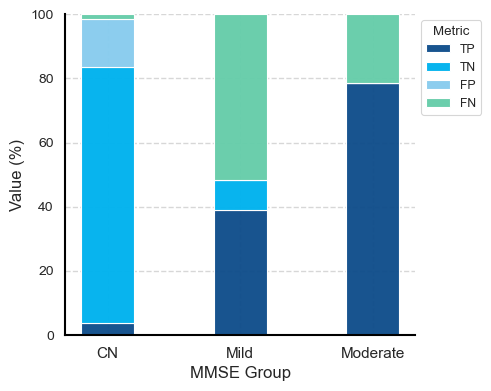

In [180]:
categories = ['CN', 'Mild', 'Moderate']

with plotting.paper_theme():
    # Plotting
    fig, ax = plt.subplots(figsize=(5, 4))

    bar_width = 0.4

    bottom = 0
    for i, prop in enumerate(props_mmse1):
        ax.bar(categories[0], prop, width=bar_width, bottom=bottom, color=colors[i], edgecolor='white')
        bottom += prop


    bottom = 0
    for i, prop in enumerate(props_mmse2):
        ax.bar(categories[1], prop, width=bar_width, bottom=bottom, color=colors[i], edgecolor='white')
        bottom += prop


    bottom = 0
    for i, prop in enumerate(props_mmse3):
        ax.bar(categories[2], prop, width=bar_width, bottom=bottom, color=colors[i], edgecolor='white')
        bottom += prop

    # bottom = 0
    # for i, prop in enumerate(props_mmse4):
    #     ax.bar(categories[3], prop, width=bar_width, bottom=bottom, color=colors[i], edgecolor='white')
    #     bottom += prop

    ax.set_ylabel('Value (%)', fontsize=12)
    ax.set_xlabel('MMSE Group', fontsize=12)
    # ax.set_title('Confusion Matrix Metrics by Age (GPT features)')
    ax.legend(['TP', 'TN', 'FP', 'FN'], title='Metric', bbox_to_anchor=(1, 1))

     # Adjusting the y-axis to show percentages
    ax.set_ylim(0, 1)
    ax.set_yticklabels(['{:.0f}'.format(y*100) for y in ax.get_yticks()], fontsize=10)
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(categories, fontsize=11)

    plt.tight_layout()
    plt.savefig('./[figs]/splits_mmse.pdf', dpi=600)
    plt.savefig('./[figs]/splits_mmse.png', dpi=600)
    plt.show()

## Calibration and reliability

In [3]:
with open('./FEATURES/dfs/liwc22-size100.pkl', 'rb') as f:
    train_size100 = pickle.load(f)

with open('./FEATURES/test-features/dfs/liwc22-size100.pkl', 'rb') as f:
    test_size100 = pickle.load(f)

with open('./external/lu/liwc/liwc22-size100-raw.pkl', 'rb') as f:
    ext_size100 = pickle.load(f)

with open('./external/hri/liwc/newLIWC22/df_liwc_all-size100.pkl', 'rb') as f:
    hri_size100 = pickle.load(f)

groups = pd.read_csv('mapping.csv')


with open('./evaluation-test-UPD/liwc22-size100-probs.pkl', 'rb') as f:
    liwc_proba100 = pickle.load(f)
liwc_proba100 = liwc_proba100['Random Forest']

In [4]:
with open('./FEATURES/test-features/dfs/liwc22-size100.pkl', 'rb') as f:
    test_size100 = pickle.load(f)
y_test = test_size100['label']

groups = pd.read_csv('mapping.csv')
groups['mapping'] = groups['mapping'].str.replace('adrsdt', '')
groups.rename(columns={'mapping': 'pid'}, inplace=True)

with open('./evaluation-test-UPD/liwc22-size100-probs.pkl', 'rb') as f:
    liwc_proba100 = pickle.load(f)
liwc_proba100 = liwc_proba100['Random Forest']

results=[]
# Iterate over the probabilities and runs
for run, probs in enumerate(liwc_proba100):
    # Create a DataFrame for each run
    run_df = pd.DataFrame({
        'pid': test_size100['pid'],
        'prob': probs.round(2),
        'y_true': test_size100['label'],
        'run': run
    })
    
    # Append the DataFrame to the results list
    results.append(run_df)

# Concatenate all the results into a single DataFrame
df_all = pd.concat(results).reset_index(drop=True)
df_all.head()

,pid,prob,y_true,run
0,58,0.24,0,0
1,64,0.52,1,0
2,70,0.60,1,0
3,71,0.83,1,0
4,65,0.25,0,0


In [5]:
groups = pd.read_csv('mapping.csv')
groups['merge'] = groups['mapping'].str.extract(r'dt(\d+)')
merged_df_all = df_all.merge(groups, left_on='pid', right_on='merge', how='left')
merged_df_all['gender'] = merged_df_all['gender'].map({'female': 'F', 'male': 'M'}).fillna('NA')
s = ['pid', 'mmse', 'prob', 'y_true', 'mmse_split', 'age_split', 'run']
merged_df_all = merged_df_all[s]
# we dont know the value of MMSE but know its CN group
merged_df_all.loc[merged_df_all['pid'] == '54', 'mmse_split'] = 'cn'
merged_df_all.loc[merged_df_all['pid'] == '54', 'mmse'] = 28
# y_test
y_test_boots = merged_df_all.y_true
merged_df_all.head()

,pid,mmse,prob,y_true,mmse_split,age_split,run
0,58,29.0,0.24,0,cn,70-80,0
1,64,24.0,0.52,1,ad-mil,60-69,0
2,70,18.0,0.60,1,ad-mod,50-59,0
3,71,24.0,0.83,1,ad-mil,70-80,0
4,65,30.0,0.25,0,cn,50-59,0


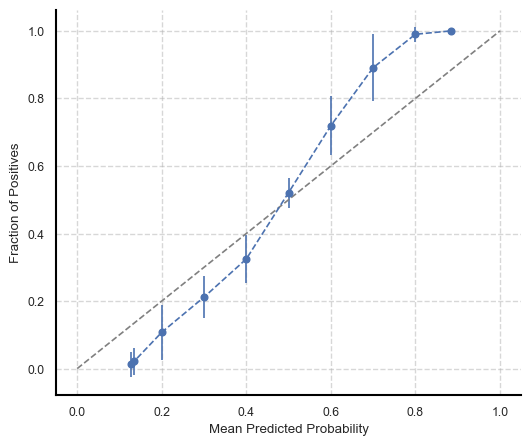

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.utils import resample

# Initialize lists to store mean predicted probabilities and fraction of positives per run
mean_pred_prob_list = []
fraction_of_positives_list = []
n_bins = 10

# Create fixed bin edges to ensure consistent binning across all runs
bin_edges = np.linspace(0, 1, n_bins + 1)

# Group by 'run' column to calculate calibration curves for each run
for run, group in merged_df_all.groupby('run'):
    # Get the true labels and predicted probabilities for each run
    y_true_run = group['y_true']
    y_prob_run = group['prob']
    
    # Calculate the calibration curve using the pre-defined bin edges
    prob_true, prob_pred = calibration_curve(y_true_run, y_prob_run, n_bins=n_bins, strategy='uniform')
    
    # Interpolate prob_true and prob_pred to match the fixed bin edges
    prob_pred_interp = np.interp(bin_edges[:-1], prob_pred, prob_pred)
    prob_true_interp = np.interp(bin_edges[:-1], prob_pred, prob_true)
    
    # Append the interpolated results
    mean_pred_prob_list.append(prob_pred_interp)
    fraction_of_positives_list.append(prob_true_interp)

# Convert lists to arrays for easier calculation of mean and std
mean_pred_prob_array = np.array(mean_pred_prob_list)
fraction_of_positives_array = np.array(fraction_of_positives_list)

# Calculate means and standard deviations across runs
mean_pred_prob_mean = np.mean(mean_pred_prob_array, axis=0)
fraction_of_positives_mean = np.mean(fraction_of_positives_array, axis=0)
fraction_of_positives_std = np.std(fraction_of_positives_array, axis=0)

with plotting.paper_theme():
    # Plot the calibration curve with error bars (representing the std deviation across runs)
    plt.figure(figsize=(6, 5))
    plt.errorbar(mean_pred_prob_mean, fraction_of_positives_mean, yerr=fraction_of_positives_std, fmt='o', linestyle='--', color='b', label='Calibration with Runs')

    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')

    plt.xlabel('Mean Predicted Probability')
    plt.ylabel('Fraction of Positives')

    # Show the plot
    plt.show()


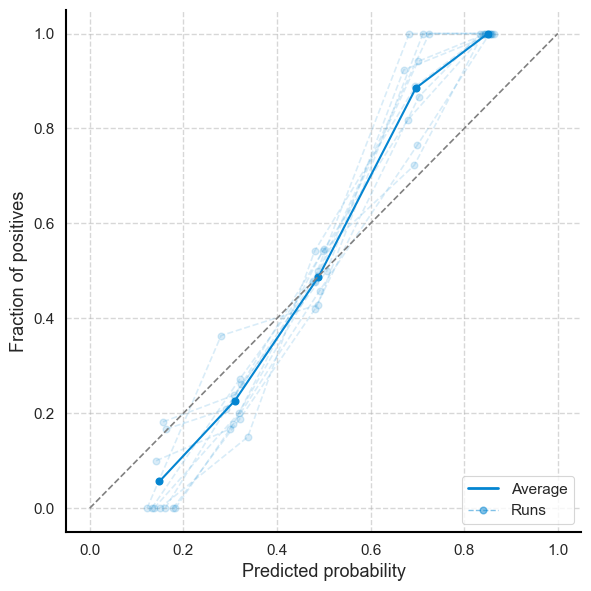

In [10]:
from sklearn.calibration import calibration_curve

n_bins = 5

calibration_curve_results = [calibration_curve(y_test, y_proba, n_bins=n_bins) for y_proba in liwc_proba100]
calibration_curve_results = pd.concat(
    [
        pd.DataFrame(cc_result, index=["Fraction Positives", "Predicted Probability"]).T.assign(Run=run)
        for run, cc_result in enumerate(calibration_curve_results)
    ]
)

average_calibration_curve = calibration_curve(
    np.tile(y_test.values, len(liwc_proba100)), 
    np.concatenate(liwc_proba100), 
    n_bins=n_bins
)

with plotting.paper_theme():
    plt.close()

    # colour = "xkcd:dark pink"
    colour ='xkcd:cerulean'

    fig, ax = plt.subplots(1,1, figsize=(6,6))

    
    for run, df in calibration_curve_results.groupby("Run"):
        prob_pred = df["Predicted Probability"]
        prob_true = df["Fraction Positives"]
        ax.plot(prob_pred, prob_true, '--', marker= "o", label=f'Run {run+1}', alpha=0.15, color=colour)

    ax.plot(
        average_calibration_curve[1], 
        average_calibration_curve[0], 
        '-',  
        marker= "o",  
        label='Average', 
        color=colour, 
        linewidth=1.5
    )
    
    ax.plot([0, 1], [0, 1], '--', color='grey')
    ax.set_xlabel('Predicted probability', fontsize=13)
    ax.set_ylabel('Fraction of positives', fontsize=13)
    # ax.set_title('Calibration curve')
    ax.tick_params(axis='both', which='major', labelsize=11)

    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(-0.05, 1.05)

    ax.legend(
        handles=[
            plt.Line2D([0], [0], color=colour, lw=2, label='Average'),
            plt.Line2D([0], [0], linestyle="--", marker= "o", color=colour, lw=1, alpha=0.5, label='Runs')
        ],
        loc='lower right',
        fontsize=11
    )
    plt.tight_layout()
    plt.savefig('./[figs]/calibration.pdf', dpi=600)
    plt.savefig('./[figs]/calibration.png', dpi=600)

    plt.show()


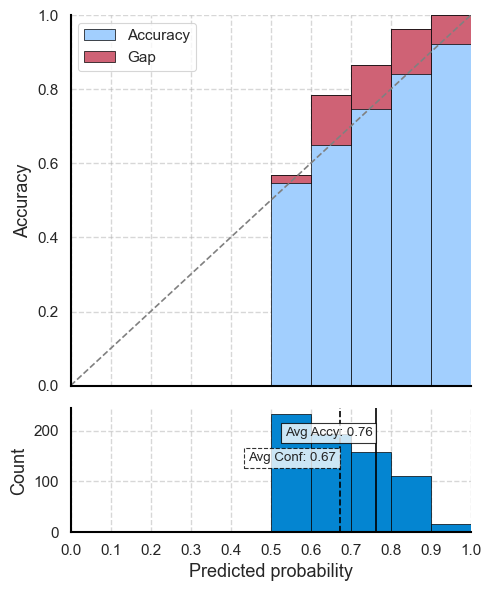

In [11]:
with plotting.paper_theme():
    plt.close()

    fig, (ax1, ax2) = plt.subplots(
        2, 1, 
        figsize=(5, 6), 
        sharex=True, 
        gridspec_kw={'height_ratios': [3, 1]},
    )
    
    ax1, ax2 = plotting.ReliabilityDisplay.from_predictions(
        np.tile(y_test.values, len(liwc_proba100)), 
        np.stack([1-np.concatenate(liwc_proba100), np.concatenate(liwc_proba100)], axis=-1),
        bar_kwargs=dict(
            linewidth=0.5,
            edgecolor='black'
        ),
        histogram_kwargs=dict(
            linewidth=0.5,
            edgecolor='black',
        ),
        diagonal_color='grey',
        ax1=ax1,
        ax2=ax2,
    )

    ax2.set_xlabel('Predicted probability', fontsize=13)
    ax2.set_ylabel('Count', fontsize=13)
    ax1.set_ylabel('Accuracy', fontsize=13)
    ax1.legend(fontsize=11)

    ax1.set_xticks(np.arange(0, 1.1, 0.1))
    ax2.set_xticks(np.arange(0, 1.1, 0.1))
    ax1.tick_params(axis='both', which='major', labelsize=11)
    ax2.set_xticklabels(np.arange(0, 1.1, 0.1).round(2))
    ax2.tick_params(axis='both', which='major', labelsize=11)

    fig.subplots_adjust(hspace=0.1)
    plt.tight_layout()
    plt.savefig('./[figs]/reliability.pdf', dpi=600)
    plt.savefig('./[figs]/reliability.png', dpi=600)

    plt.show()

## New regression

In [14]:
with open('./FEATURES/dfs/liwc22-size100.pkl', 'rb') as f:
    train_size100 = pickle.load(f)

with open('./FEATURES/test-features/dfs/liwc22-size100.pkl', 'rb') as f:
    test_size100 = pickle.load(f)

with open('./external/lu/liwc/liwc22-size100-raw.pkl', 'rb') as f:
    ext_size100 = pickle.load(f)

with open('./external/hri/liwc/newLIWC22/df_liwc_all-size100.pkl', 'rb') as f:
    hri_size100 = pickle.load(f)

groups = pd.read_csv('mapping.csv')

with open(f'./evaluation-test-UPD/predict_reg/predicted_liwc_size100.pkl', 'rb') as f:
    predicted = pickle.load(f)

bestmodel = 'RFR'
probs_bestmodel = predicted[f'{bestmodel}']
probs_bestmodel

[array([22.48483333, 21.63815476, 19.87016667, 15.253     , 26.76742857,
        25.41427778, 21.8842381 , 26.1132381 , 21.89444048, 18.85130952,
        26.7835    , 21.56519048, 21.12547619, 28.89833333, 19.10890476,
        12.58691667, 20.02788095, 28.49678571, 27.10369048, 26.14738095,
        25.95359524, 17.40858333, 21.37730952, 16.69135714, 20.11346429,
        22.38634524, 23.77729762, 22.64171429, 26.08347619, 23.52621429,
        21.86053571, 28.55521429, 21.60407143, 24.28159524, 24.6410119 ,
        22.41691667, 25.99403571, 26.86896429, 25.62652381, 26.27604762,
        21.5865119 , 20.6922381 , 23.25296429, 12.1045    , 25.87566667,
        27.99766667, 26.16469048, 26.22315476, 23.13235714, 27.64354762,
        18.68283333, 26.57290476, 28.13211905, 26.02728571, 18.19566667,
        28.6495    , 27.6562381 , 18.1020119 , 25.89680952, 16.8445    ,
        22.94578571, 25.89790476, 25.56078571, 22.53645238, 28.2052619 ,
        26.71835714, 22.14666667, 29.54464286, 22.6

In [13]:
groups = pd.read_csv('mapping.csv')
groups['mapping'] = groups['mapping'].str.replace('adrsdt', '')
groups.rename(columns={'mapping': 'pid'}, inplace=True)
groups = groups.sort_values('pid').reset_index(drop=True)
df_reg_test = test_size100.merge(groups, left_on='pid', right_on='pid', how='left')
# IMPORTANT: remove outlier without MMSE 
df_reg_test = df_reg_test[df_reg_test['pid'] != '54']
df_reg_test['mmse'] = df_reg_test['mmse'].round().astype(int)
df_reg_test.head()

,pid,label,data,adressfname,gender,dx,age,mmse,mmse_split,age_split
0,58,0,"[57, 47.02, 94.48, 1.0, 5.65, 8.14, 14.04, 89....",adrso013,female,Control,70,29,cn,70-80
1,64,1,"[57, 62.72, 70.59, 14.46, 74.93, 5.7, 15.79, 9...",adrso038,female,ProbableAD,65,24,ad-mil,60-69
2,70,1,"[62, 95.94, 97.31, 25.64, 6.37, 4.43, 6.45, 95...",adrso214,male,ProbableAD,56,18,ad-mod,50-59
3,71,1,"[156, 1.0, 99.0, 1.31, 49.66, 19.5, 13.46, 97....",adrso083,male,ProbableAD,78,24,ad-mil,70-80
4,65,0,"[107, 88.19, 94.26, 10.52, 48.73, 15.29, 12.15...",adrso166,female,Control,58,30,cn,50-59


In [17]:
s = ['pid', 'mmse', 'data', 'mmse_split']
df_groups = df_reg_test[s]
df_groups.loc[:, 'pid'] = df_groups['pid'].str.replace('adrsdt', '')

import numpy as np

mean_probs = np.mean(probs_bestmodel, axis=0)
mean_probs

y_proba_df_all = pd.DataFrame(mean_probs.round(2), columns=['y_pred'])
y_proba_df_all['pid'] = df_groups['pid']
y_proba_df_all['y_true'] = df_groups['mmse']
y_proba_df_all['error'] = abs(y_proba_df_all['y_true'] - y_proba_df_all['y_pred'])
y_proba_df_all['cog_group'] = df_groups['mmse_split']
y_proba_df_all.head()

/var/folders/xx/gc1pd92159b41vdn712h03ym0000gp/T/ipykernel_23491/1360113657.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_groups.loc[:, 'pid'] = df_groups['pid'].str.replace('adrsdt', '')


,y_pred,pid,y_true,error,cog_group
0,24.53,58,29.0,4.47,cn
1,21.91,64,24.0,2.09,ad-mil
2,22.04,70,18.0,4.04,ad-mod
3,16.79,71,24.0,7.21,ad-mil
4,27.90,65,30.0,2.10,cn


In [18]:
c_state_position = {
    "cn": 3,
    "ad-mil": 2,
    "ad-mod": 1,
    "ad-sev": 0,
}

y_proba_df_all_bootstrap = pd.concat([
    pd.DataFrame(probs_bestmodel[i], columns=['y_pred']).assign(
        run=i,
        pid=df_groups['pid'],
        y_true=df_groups['mmse'],
        error=abs(df_groups['mmse'] - probs_bestmodel[i]),
        cog_group=df_groups['mmse_split']
    )
    for i in range(len(probs_bestmodel))
]).reset_index(drop=True)

y_proba_df_all_bootstrap_stats = (
    y_proba_df_all_bootstrap
    .groupby(['pid'])
    .agg(
        {
            'y_pred': ['mean', 'std'],
            'pid': 'first',
            'y_true': 'first',
            'error': ['mean', 'std'],
            'cog_group': 'first'
        }
    )
    .assign(
        xpos = lambda x: x['cog_group']['first'].map(c_state_position)
    )
    .reset_index()
)

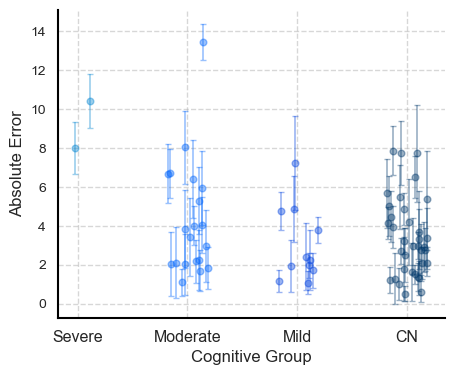

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Define the order of the cognitive groups
cog_group_order = ['ad-sev', 'ad-mod', 'ad-mil', 'cn']
labels = ['Severe', 'Moderate', 'Mild', 'CN']

# make all colours the same if you dont like 
# the colour change for each group
colors = [
    'xkcd:cerulean',
    'xkcd:bright blue',
    'xkcd:blue',
    'xkcd:marine blue',
]  

jitter_min = -0.2
jitter_max = 0.2

jitter_seed = 42

plt.close()
# Use your desired plotting theme (e.g., paper_theme)
with plotting.paper_theme():  # Assuming `plotting.paper_theme()` is defined elsewhere in your code
    fig, ax = plt.subplots(1,1,figsize=(5, 4))
    
    # Create the strip plot with the desired order and single color
    for c_state in cog_group_order:
        y_proba_df_all_bootstrap_stats_c_state = y_proba_df_all_bootstrap_stats[y_proba_df_all_bootstrap_stats['cog_group']['first'] == c_state]

        ax.errorbar(
            (
                y_proba_df_all_bootstrap_stats_c_state['xpos'] 
                + np.random.default_rng(jitter_seed).uniform(
                    jitter_min, 
                    jitter_max, 
                    len(y_proba_df_all_bootstrap_stats_c_state)
                )
            ),
            y_proba_df_all_bootstrap_stats_c_state['error']['mean'],
            yerr=y_proba_df_all_bootstrap_stats_c_state['error']['std'],
            fmt='o',
            alpha=0.4,
            capsize=2,
            color=colors[c_state_position[c_state]],
        )

    ax.set_xlabel('Cognitive Group', fontsize=12)
    ax.set_ylabel('Absolute Error', fontsize=12)
    ax.tick_params(labelsize=10)
    ax.set_xticks(np.arange(4), labels, fontsize=11.5)  # Set x-axis labels
    
    plt.show()


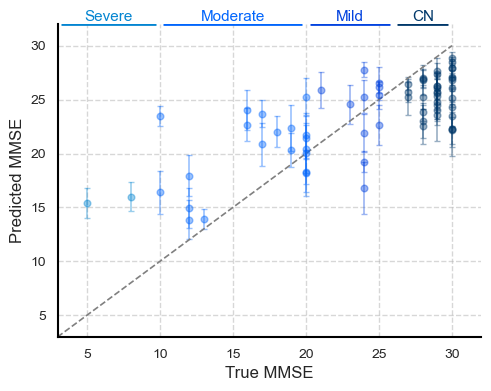

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Define the order of the cognitive groups
cog_group_order = ['ad-sev', 'ad-mod', 'ad-mil', 'cn']
labels = ['Severe', 'Moderate', 'Mild', 'CN']


# make all colours the same if you dont like 
# the colour change for each group
colors = [
    'xkcd:cerulean',
    'xkcd:bright blue',
    'xkcd:blue',
    'xkcd:marine blue',
]  

jitter_min = -0.2
jitter_max = 0.2

jitter_seed = 42

plt.close()
# Use your desired plotting theme (e.g., paper_theme)
with plotting.paper_theme():  # Assuming `plotting.paper_theme()` is defined elsewhere in your code
    fig, ax = plt.subplots(1,1,figsize=(5, 4))
    
    # Create the strip plot with the desired order and single color
    for c_state in cog_group_order:
        y_proba_df_all_bootstrap_stats_c_state = y_proba_df_all_bootstrap_stats[y_proba_df_all_bootstrap_stats['cog_group']['first'] == c_state]

        ax.errorbar(
            y_proba_df_all_bootstrap_stats_c_state['y_true']['first'],
            y_proba_df_all_bootstrap_stats_c_state['y_pred']['mean'],
            yerr=y_proba_df_all_bootstrap_stats_c_state['y_pred']['std'],
            fmt='o',
            alpha=0.4,
            capsize=2,
            color=colors[c_state_position[c_state]],
        )

    ax.set_xlabel('True MMSE', fontsize=12)
    ax.set_ylabel('Predicted MMSE', fontsize=12)
    ax.tick_params(labelsize=10)
    ax.set_xticks(np.arange(0, 30.5, 5))  # Set x-axis labels
    ax.set_yticks(np.arange(0, 30.5, 5))  # Set x-axis labels
    

    # ax.set_xlim(-2, 32)
    # ax.set_ylim(-2, 32)
    


    def add_hlines(xmin, xmax, text, ax, colour):
        xmin = xmin + 0.25
        xmax = xmax - 0.25
        height = 32
        colour = colour ### choose colour name here https://xkcd.com/color/rgb/
        ax.hlines(y=height, xmin=xmin, xmax=xmax, color=colour, linestyle='-', lw=2)
        ax.text(0.5*(xmin+xmax), height+0.025, text, color=colour, fontsize=11, horizontalalignment='center', verticalalignment='bottom')


    add_hlines(3, 10, 'Severe', ax, colour=colors[0])
    add_hlines(10, 20, 'Moderate', ax, colour=colors[1])
    add_hlines(20, 26, 'Mild', ax, colour=colors[2])
    add_hlines(26, 30, 'CN', ax, colour=colors[3])

    ax.set_xticks(np.arange(5, 31, 5))  # Set x-axis labels to start at 5
    ax.set_yticks(np.arange(5, 31, 5))  # Set y-axis labels to start at 5

    ax.set_xlim(3, 32)  # Set x-axis limit to start at 5
    ax.set_ylim(3, 32)  # Set y-axis limit to start at 5
    ax.plot([3, 30], [3, 30], linestyle='--', color='gray')
    plt.tight_layout()
    plt.savefig('./[figs]/regression_new.pdf', dpi=600)
    plt.savefig('./[figs]/regression_new.png', dpi=600)



    plt.show()
